# Phân Tích Dữ Liệu Laptop — Hệ Hỗ Trợ Quyết Định (DSS)

**Mục tiêu:** Phân tích tập dữ liệu `laptops_dataset_cleaned.csv` để phát hiện insight phục vụ xây dựng DSS tư vấn mua laptop.

**Các bước phân tích:**
1. Thống kê mô tả & tổng quan dữ liệu
2. Phân tích theo nhóm (Brand, phân khúc giá)
3. Trực quan hóa dữ liệu
4. Phát hiện xu hướng, bất thường, mối quan hệ
5. Insight gắn với bài toán quyết định DSS

---

## Import Thư Viện

In [1]:
# ─── Import các thư viện cần thiết ───────────────────────────────────────────
import pandas as pd                    # Xử lý và phân tích dữ liệu dạng bảng
import numpy as np                     # Tính toán số học, mảng đa chiều
import matplotlib.pyplot as plt        # Vẽ biểu đồ cơ bản
import matplotlib.ticker as mtick      # Định dạng trục biểu đồ
import seaborn as sns                  # Vẽ biểu đồ thống kê nâng cao
import warnings                        # Kiểm soát cảnh báo

# ─── Cấu hình toàn cục ────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')      # Ẩn các cảnh báo không cần thiết
plt.rcParams['figure.dpi'] = 120       # Độ phân giải biểu đồ cao hơn
plt.rcParams['font.family'] = 'DejaVu Sans'  # Font chữ mặc định
sns.set_theme(style='whitegrid', palette='muted')  # Theme seaborn nhất quán

# ─── Hằng số đường dẫn ────────────────────────────────────────────────────────
DATA_PATH = '../data/laptops_dataset_cleaned.csv'  # Đường dẫn tới file CSV

print('Import thư viện thành công!')

Import thư viện thành công!


---
## Phần 1 — Thống Kê Mô Tả & Tổng Quan Dữ Liệu

### 1.1 Load dữ liệu và kiểm tra cơ bản

In [2]:
# ─── Đọc file CSV vào DataFrame ───────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)            # Đọc toàn bộ file CSV

# ─── Kiểm tra số dòng & cột ───────────────────────────────────────────────────
n_rows, n_cols = df.shape              # shape trả về tuple (số_dòng, số_cột)
print(f'Số dòng (mẫu dữ liệu): {n_rows:,}')
print(f'Số cột (thuộc tính):   {n_cols}')
print(f'Tên các cột: {list(df.columns)}')
print('\n' + '='*70)

# ─── Hiển thị 5 dòng đầu ──────────────────────────────────────────────────────
print('\n5 dòng đầu tiên:')
df.head()                              # Xem nhanh cấu trúc dữ liệu

Số dòng (mẫu dữ liệu): 1,011
Số cột (thuộc tính):   24
Tên các cột: ['brand', 'product_name', 'processor', 'video_graphics', 'video_graphics_memory', 'ram', 'hard_drive', 'display', 'display_resolution', 'display_refresh_rate', 'operating_system', 'keyboard', 'battery', 'webcam', 'connections', 'dimensions', 'weight', 'colors', 'warranty', 'price', 'cpu_point', 'gpu_point', 'ram_capacity', 'storage']


5 dòng đầu tiên:


,brand,product_name,processor,video_graphics,video_graphics_memory,ram,hard_drive,display,display_resolution,display_refresh_rate,...,connections,dimensions,weight,colors,warranty,price,cpu_point,gpu_point,ram_capacity,storage
0,MSI,Titan 18 HX Dragon Edition Norse Myth A2XWJG,Intel Core Ultra 9 285HX,Nvidia GeForce RTX 5090 24GB,24GB GDDR7,96GB DDR5 6400MHz 48GB*2,"6TB, 2TB NVMe PCIe Gen5x4 SSD w/o DRAM + 2TB N...","18"" 16:10 UHD+ (3840x2400), MiniLED, 120Hz, 10...",3840x2400,120 Hz,...,2x Thunderbolt™ 5 (DisplayPort™/ Power Deliver...,404 x 307.5 x 24-32.05 mm,3.6,Core Black,2 Years,162000000,83.0,67.0,96,10240
1,MSI,Katana 15 HX 14XWGK,Intel Core i9-14900HX,Nvidia GeForce RTX 5070 8GB,8GB GDDR7,16GB DDR5 8GB*2,1TB NVMe PCIe SSD Gen4x4,"15.6"" QHD (2560*1440), 165Hz DCI-P3 100% typical",2560x1440,165 Hz,...,1x USB Type-C (USB 3.2 Gen2 / DisplayPort / Po...,359 x 262 x 25.5 mm,2.4,Black,2 Years,40500000,72.0,54.0,16,1024
2,Acer,NITRO V15-ANV15-51-51H9,Intel Core I5-13420H,Nvidia GeForce RTX 4050 6GB,6GB GDDR6,8 GB DDR5-SDRAM,512 GB SSD,15.6'' Inch FHD IPS LED backlight aspect ratio...,1920x1080,144 Hz,...,USB 3.2 Gen 1 (3.1 Gen 1) Type-A ports quantit...,362.3 x 237.4 x 19.9 mm,1.8,Black,1 Year,20200000,50.0,33.0,8,512
3,Dell,Alienware 16 Aurora AC16250,Intel Core 7 240H,NVIDIA(R) GeForce RTX(TM) 5050,8 GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s ( 5200 MT/s with ...",512GB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560x1600,120 Hz,...,2 USB 3.2 Gen 1 (5 Gbps) ports 1 USB 3.2 Gen 2...,356.98 x 265.43 x 15.20 mm,2.5,Black,1 Year,29400000,57.0,38.0,16,512
4,Dell,Alienware 16 Aurora AC16250,Intel Core 9 270H,Nvidia GeForce RTX 5060 8GB,8GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s",1TB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560x1600,120 Hz,...,2 USB Type-A 3.2 Gen 1 Port 1 Type-C® Port (US...,356.98 x 265.43 x 22.70 mm,2.5,Black,1 Year,45600000,61.0,44.0,16,1024


In [3]:
# ─── Kiểm tra kiểu dữ liệu của từng cột ──────────────────────────────────────
print('- Kiểu dữ liệu của từng cột:')
print(df.dtypes)                       # Hiển thị dtype: int64, float64, object...

print('\n' + '='*70)

# ─── Thông tin tổng quát (non-null count & dtype) ─────────────────────────────
print('\n- Thông tin tổng quát của DataFrame:')
df.info()                              # Số giá trị không null, bộ nhớ sử dụng

- Kiểu dữ liệu của từng cột:
brand                     object
product_name              object
processor                 object
video_graphics            object
video_graphics_memory     object
ram                       object
hard_drive                object
display                   object
display_resolution        object
display_refresh_rate      object
operating_system          object
keyboard                  object
battery                   object
webcam                    object
connections               object
dimensions                object
weight                   float64
colors                    object
warranty                  object
price                      int64
cpu_point                float64
gpu_point                float64
ram_capacity               int64
storage                    int64
dtype: object


- Thông tin tổng quát của DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 24 columns):
 #   Column        

### 1.2 Kiểm tra và xử lý dữ liệu khuyết thiếu & trùng lặp

In [4]:
# ─── Kiểm tra Missing Values ──────────────────────────────────────────────────
missing = df.isnull().sum()            # Đếm số giá trị null/NaN theo từng cột
missing_pct = (missing / len(df)) * 100  # Tính tỷ lệ phần trăm

# Tạo bảng tóm tắt missing values
missing_report = pd.DataFrame({
    'Số lượng thiếu': missing,
    'Tỷ lệ (%)': missing_pct.round(2)
}).sort_values('Số lượng thiếu', ascending=False)  # Sắp xếp theo số lượng thiếu

print('🔍 Báo cáo Missing Values:')
print(missing_report[missing_report['Số lượng thiếu'] > 0])  # Chỉ hiện cột có missing

if missing.sum() == 0:
    print('✅ Không có missing values trong dataset!')

print('\n' + '='*70)

# ─── Kiểm tra dữ liệu trùng lặp ──────────────────────────────────────────────
n_duplicates = df.duplicated().sum()   # Đếm số dòng trùng hoàn toàn
print(f'\n🔍 Số dòng trùng lặp: {n_duplicates}')

if n_duplicates > 0:
    # Nếu có trùng lặp → xóa và giữ lại dòng đầu tiên
    df = df.drop_duplicates(keep='first')  # keep='first': giữ bản ghi đầu tiên
    print(f'Đã xóa {n_duplicates} dòng trùng lặp. Dataset còn {len(df)} dòng.')
else:
    print('✅ Không có dòng trùng lặp trong dataset!')

🔍 Báo cáo Missing Values:
Empty DataFrame
Columns: [Số lượng thiếu, Tỷ lệ (%)]
Index: []
✅ Không có missing values trong dataset!


🔍 Số dòng trùng lặp: 0
✅ Không có dòng trùng lặp trong dataset!


In [5]:
# ─── Làm sạch cột 'weight' (trọng lượng) ─────────────────────────────────────
# Cột weight có thể chứa ký tự 'kg' hoặc khoảng trắng, cần chuyển sang float
def clean_weight(val):
    """Hàm làm sạch giá trị weight:
    - Loại bỏ ký tự không phải số (kg, lbs, spaces)
    - Chuyển về kiểu float
    - Trả về NaN nếu không parse được
    """
    try:
        # Loại bỏ các ký tự không phải số và dấu chấm
        cleaned = str(val).lower().replace('kg', '').replace('lbs', '').strip()
        return float(cleaned)
    except (ValueError, TypeError):
        return np.nan  # Trả về NaN nếu không thể chuyển đổi

# Áp dụng hàm làm sạch lên cột weight
df['weight_clean'] = df['weight'].apply(clean_weight)

# ─── Đảm bảo cột 'price' là số ───────────────────────────────────────────────
df['price'] = pd.to_numeric(df['price'], errors='coerce')  # 'coerce': lỗi → NaN

# ─── Tạo cột giá tính bằng triệu VNĐ để dễ đọc ──────────────────────────────
df['price_M'] = df['price'] / 1_000_000  # Chia 1 triệu để đơn vị là triệu VNĐ

# ─── Đảm bảo các cột điểm số là số ──────────────────────────────────────────
df['cpu_point'] = pd.to_numeric(df['cpu_point'], errors='coerce')
df['gpu_point'] = pd.to_numeric(df['gpu_point'], errors='coerce')
df['ram_capacity'] = pd.to_numeric(df['ram_capacity'], errors='coerce')
df['storage'] = pd.to_numeric(df['storage'], errors='coerce')

print('Đã làm sạch các cột số thành công!')
print(f"Thống kê nhanh sau làm sạch:")
print(df[['price_M', 'weight_clean', 'cpu_point', 'gpu_point', 'ram_capacity']].describe().round(2))

Đã làm sạch các cột số thành công!
Thống kê nhanh sau làm sạch:
       price_M  weight_clean  cpu_point  gpu_point  ram_capacity
count  1011.00       1011.00    1011.00    1011.00       1011.00
mean     25.14          2.02      54.74      23.84         14.95
std      18.28          0.46       7.19      16.29          9.52
min       4.30          0.90      13.00       0.00          4.00
25%      14.35          1.70      50.00      16.00          8.00
50%      20.00          2.00      53.00      28.00         16.00
75%      29.20          2.30      57.00      33.00         16.00
max     162.00          4.30      83.00      67.00         96.00


### 1.3 Thống kê mô tả cơ bản cho biến định lượng

In [6]:
# ─── Tính các thống kê mô tả cho biến định lượng quan trọng ──────────────────
# Chọn các cột cần thống kê
quantitative_cols = ['price_M', 'weight_clean', 'cpu_point', 'gpu_point', 'ram_capacity', 'storage']

# Tạo bảng thống kê thủ công để kiểm soát format
stats_data = []
for col in quantitative_cols:
    series = df[col].dropna()          # Bỏ NaN trước khi tính
    stats_data.append({
        'Cột': col,
        'Số quan sát': len(series),
        'Trung bình (mean)': series.mean().round(2),
        'Trung vị (median)': series.median().round(2),
        'Nhỏ nhất (min)': series.min().round(2),
        'Lớn nhất (max)': series.max().round(2),
        'Độ lệch chuẩn (std)': series.std().round(2)
    })

# Chuyển thành DataFrame để hiển thị dạng bảng
stats_df = pd.DataFrame(stats_data).set_index('Cột')

print('THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH LƯỢNG:')
print('=' * 80)
print(stats_df.to_string())

# ─── Phân tích ý nghĩa ────────────────────────────────────────────────────────
price_mean = df['price_M'].mean()
price_median = df['price_M'].median()
price_min = df['price_M'].min()
price_max = df['price_M'].max()

print(f'\nNHẬN XÉT THỐNG KÊ GIÁ BÁN:')
print(f'   • Giá trung bình: {price_mean:.1f} triệu VNĐ')
print(f'   • Giá trung vị:   {price_median:.1f} triệu VNĐ')
print(f'   • Giá thấp nhất:  {price_min:.1f} triệu VNĐ')
print(f'   • Giá cao nhất:   {price_max:.1f} triệu VNĐ')
if price_mean > price_median:
    print(f'   → Mean > Median: Phân phối lệch phải (right-skewed), có các sản phẩm giá rất cao kéo mean lên.')
else:
    print(f'   → Mean ≤ Median: Phân phối tương đối đối xứng hoặc lệch trái.')

THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH LƯỢNG:
              Số quan sát  Trung bình (mean)  Trung vị (median)  Nhỏ nhất (min)  Lớn nhất (max)  Độ lệch chuẩn (std)
Cột                                                                                                                 
price_M              1011              25.14               20.0             4.3           162.0                18.28
weight_clean         1011               2.02                2.0             0.9             4.3                 0.46
cpu_point            1011              54.74               53.0            13.0            83.0                 7.19
gpu_point            1011              23.84               28.0             0.0            67.0                16.29
ram_capacity         1011              14.95               16.0             4.0            96.0                 9.52
storage              1011             750.24              512.0           128.0         10240.0               569.23

NHẬN XÉT THỐNG KÊ GIÁ BÁN:


---
## Phần 2 — Phân Tích Theo Nhóm

### 2.1 Phân tích giá trung bình theo Hãng sản xuất (Brand)

In [7]:
# ─── Tính giá trung bình, trung vị, min, max theo Brand ──────────────────────
brand_stats = df.groupby('brand')['price_M'].agg(
    so_luong_san_pham='count',         # Số lượng sản phẩm của mỗi hãng
    gia_trung_binh='mean',             # Giá trung bình (mean)
    gia_trung_vi='median',             # Giá trung vị (median) - ít bị ảnh hưởng bởi outlier
    gia_thap_nhat='min',               # Giá thấp nhất
    gia_cao_nhat='max'                 # Giá cao nhất
).round(2)

# Sắp xếp theo giá trung bình giảm dần
brand_stats = brand_stats.sort_values('gia_trung_binh', ascending=False)

print('THỐNG KÊ GIÁ BÁN THEO HÃNG SẢN XUẤT (triệu VNĐ):')
print('=' * 70)
print(brand_stats.to_string())

# ─── Nhận xét ─────────────────────────────────────────────────────────────────
top_brand = brand_stats.index[0]
bottom_brand = brand_stats.index[-1]
print(f'\nNHẬN XÉT:')
print(f'   • Hãng có giá TB cao nhất: {top_brand} ({brand_stats.loc[top_brand, "gia_trung_binh"]:.1f} triệu)')
print(f'   • Hãng có giá TB thấp nhất: {bottom_brand} ({brand_stats.loc[bottom_brand, "gia_trung_binh"]:.1f} triệu)')

THỐNG KÊ GIÁ BÁN THEO HÃNG SẢN XUẤT (triệu VNĐ):
           so_luong_san_pham  gia_trung_binh  gia_trung_vi  gia_thap_nhat  gia_cao_nhat
brand                                                                                  
Microsoft                  9           49.52         40.50           33.2          78.5
MSI                      113           35.98         26.40            6.3         162.0
ASUS                     252           29.61         23.85            4.5         103.8
Razer                      2           28.95         28.95           25.3          32.6
Lenovo                   264           23.33         19.70            5.2         118.9
Dell                     128           20.36         17.80            4.6          74.6
HP                       203           20.24         18.70            5.1         101.2
Unknown                    2           14.65         14.65           11.6          17.7
Acer                      29           13.70         12.70            7

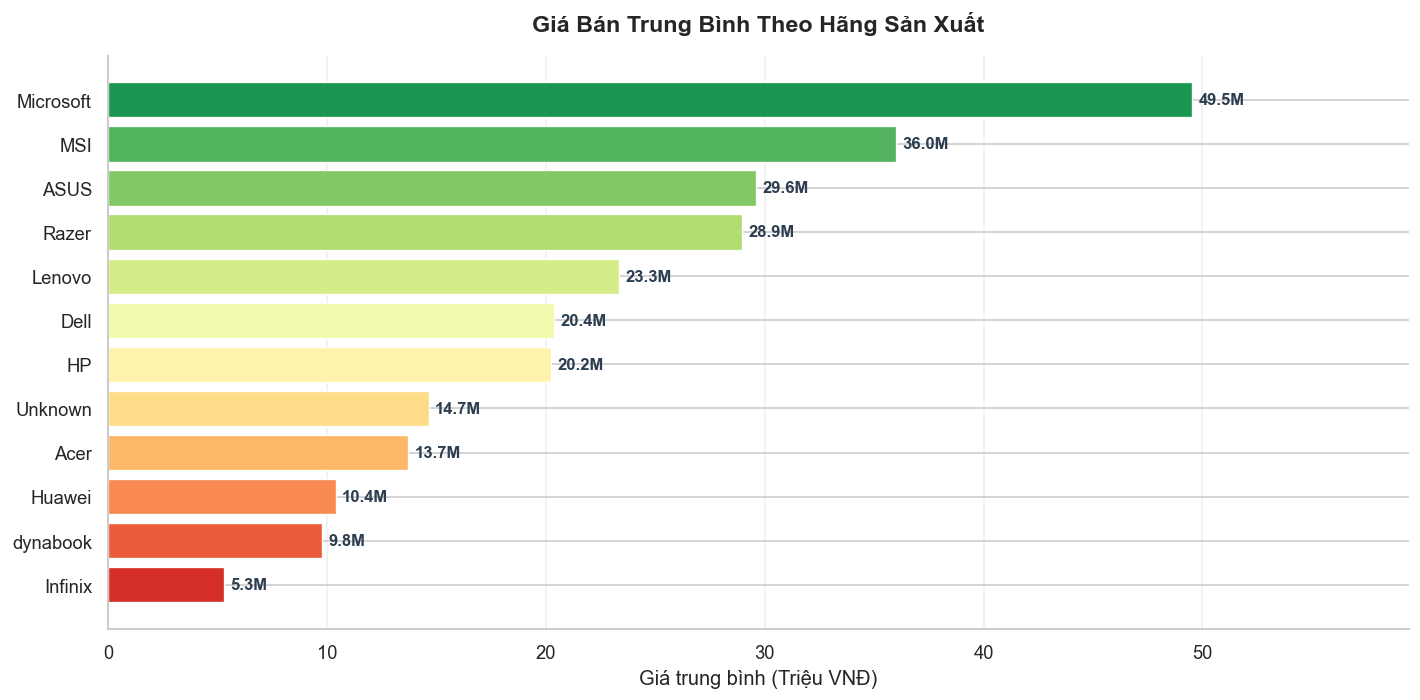

Biểu đồ đã lưu: assets/01_avg_price_by_brand.png


In [8]:
# ─── Trực quan hóa: Giá trung bình theo Brand ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# Lấy dữ liệu đã sắp xếp
brands = brand_stats.index.tolist()        # Danh sách hãng
avg_prices = brand_stats['gia_trung_binh'].values  # Mảng giá TB

# Vẽ bar chart ngang với màu gradient từ xanh đến đỏ theo giá
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(brands)))  # Màu sắc gradient
bars = ax.barh(brands, avg_prices, color=colors, edgecolor='white', linewidth=0.8)

# Thêm nhãn giá trị lên mỗi thanh
for bar, val in zip(bars, avg_prices):
    ax.text(val + 0.3,                  # Vị trí x (sau thanh một chút)
            bar.get_y() + bar.get_height()/2,  # Vị trí y (giữa thanh)
            f'{val:.1f}M',             # Nhãn giá trị
            va='center', fontsize=10, fontweight='bold', color='#2c3e50')

# Định dạng biểu đồ
ax.set_xlabel('Giá trung bình (Triệu VNĐ)', fontsize=12)
ax.set_title('Giá Bán Trung Bình Theo Hãng Sản Xuất', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, avg_prices.max() * 1.2)  # Mở rộng trục x để có chỗ cho nhãn
ax.invert_yaxis()                       # Hãng có giá cao nhất ở trên
ax.grid(axis='x', alpha=0.3)            # Lưới ngang mờ
ax.spines[['top', 'right']].set_visible(False)  # Ẩn viền trên và phải

plt.tight_layout()
plt.savefig('../assets/01_avg_price_by_brand.png', bbox_inches='tight', dpi=150)
plt.show()
print('Biểu đồ đã lưu: assets/01_avg_price_by_brand.png')

### 2.2 Gom nhóm (Binning) theo Phân Khúc Giá

In [9]:
# ─── Định nghĩa ranh giới và nhãn phân khúc ──────────────────────────────────
# Ranh giới phân khúc theo yêu cầu bài:
#   Rẻ:       < 15 triệu VNĐ
#   Phổ thông: 15 – 25 triệu VNĐ
#   Cao cấp:  > 25 triệu VNĐ

bins_boundaries = [0, 15, 25, float('inf')]  # Ranh giới: 0, 15, 25, ∞
bins_labels = ['Rẻ (<15M)', 'Phổ thông (15-25M)', 'Cao cấp (>25M)']

# pd.cut() chia cột 'price_M' vào các nhóm theo bins_boundaries
# right=True (mặc định): khoảng (a, b] — bao gồm cận phải
df['price_segment'] = pd.cut(
    df['price_M'],
    bins=bins_boundaries,
    labels=bins_labels,
    right=True              # Khoảng (0,15], (15,25], (25,∞]
)

# ─── Đếm số lượng sản phẩm mỗi phân khúc ─────────────────────────────────────
segment_count = df['price_segment'].value_counts().sort_index()
segment_pct = (segment_count / segment_count.sum() * 100).round(1)

# Tạo bảng tóm tắt
segment_report = pd.DataFrame({
    'Số lượng máy': segment_count,
    'Tỷ lệ (%)': segment_pct
})

print('PHÂN LOẠI LAPTOP THEO PHÂN KHÚC GIÁ:')
print('=' * 50)
print(segment_report.to_string())
print(f'\nTổng: {segment_count.sum()} sản phẩm')

# ─── Nhận xét ─────────────────────────────────────────────────────────────────
dominant = segment_report['Số lượng máy'].idxmax()  # Phân khúc có nhiều nhất
print(f'\nPhân khúc chiếm ưu thế: {dominant} với {segment_report.loc[dominant, "Tỷ lệ (%)"]:.1f}% sản phẩm')

PHÂN LOẠI LAPTOP THEO PHÂN KHÚC GIÁ:
                    Số lượng máy  Tỷ lệ (%)
price_segment                              
Rẻ (<15M)                    284       28.1
Phổ thông (15-25M)           390       38.6
Cao cấp (>25M)               337       33.3

Tổng: 1011 sản phẩm

Phân khúc chiếm ưu thế: Phổ thông (15-25M) với 38.6% sản phẩm


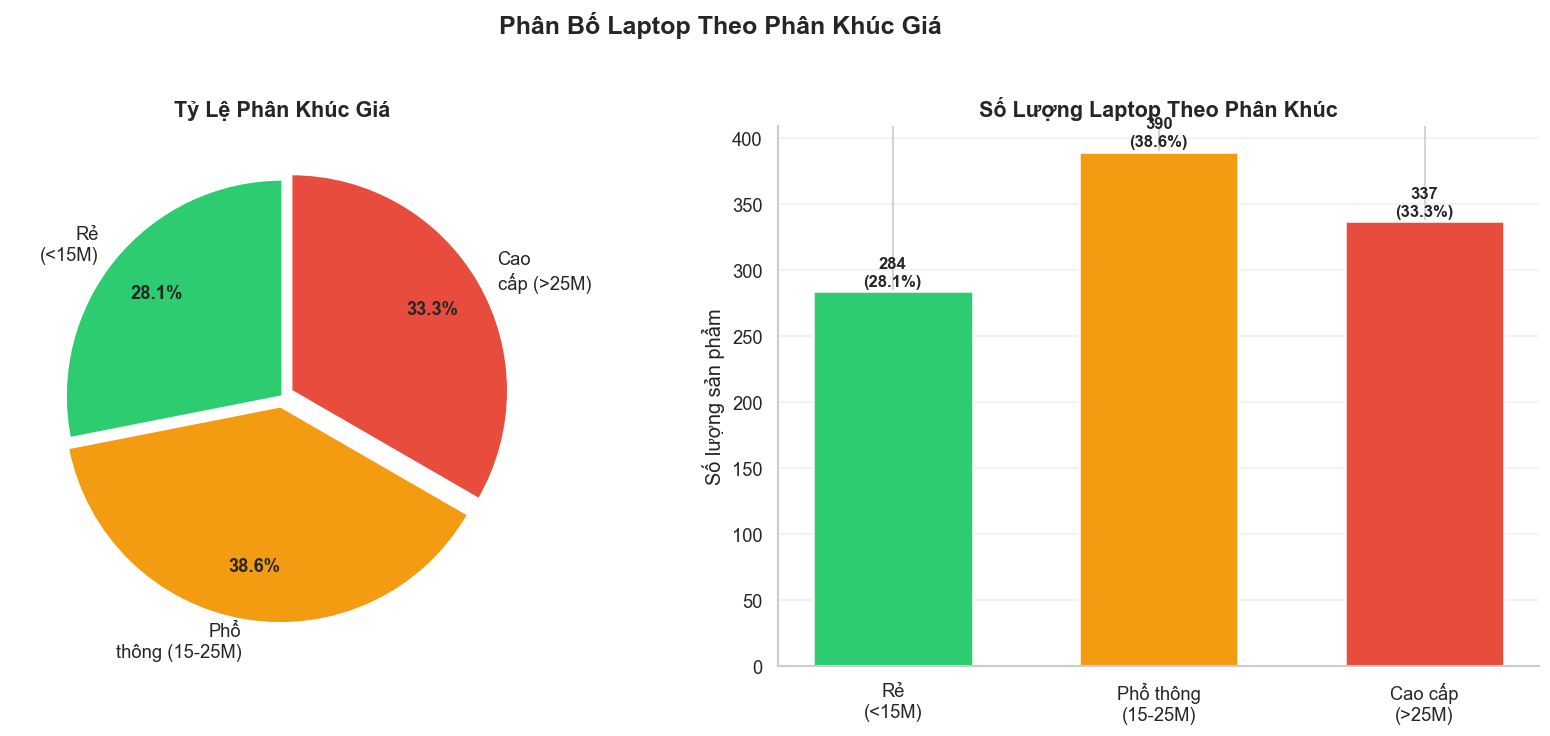

Biểu đồ đã lưu: assets/02_price_segments.png


In [10]:
# ─── Trực quan hóa phân khúc giá bằng Pie Chart & Bar Chart ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Pie Chart ---
segment_colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Xanh, vàng, đỏ
wedges, texts, autotexts = ax1.pie(
    segment_count.values,
    labels=[s.split(' ')[0] + '\n' + ' '.join(s.split(' ')[1:]) for s in segment_count.index],  # Xuống dòng
    autopct='%1.1f%%',             # Hiển thị % tự động
    colors=segment_colors,
    startangle=90,                 # Bắt đầu từ 12 giờ
    pctdistance=0.75,              # Vị trí phần trăm
    explode=(0, 0.05, 0.05)        # Tách nhẹ phân khúc TB và Cao cấp
)
for autotext in autotexts:         # Làm đậm chữ phần trăm
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax1.set_title('Tỷ Lệ Phân Khúc Giá', fontsize=13, fontweight='bold')

# --- Bar Chart ---
x_pos = range(len(segment_count))
bars2 = ax2.bar(x_pos, segment_count.values,
                color=segment_colors,
                edgecolor='white', linewidth=1.5, width=0.6)

# Thêm nhãn số lượng lên mỗi cột
for bar, cnt, pct in zip(bars2, segment_count.values, segment_pct.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,   # Hơi cao hơn đỉnh cột
             f'{cnt}\n({pct}%)',      # Hiện số lượng và %
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Rẻ\n(<15M)', 'Phổ thông\n(15-25M)', 'Cao cấp\n(>25M)'], fontsize=11)
ax2.set_ylabel('Số lượng sản phẩm', fontsize=12)
ax2.set_title('Số Lượng Laptop Theo Phân Khúc', fontsize=13, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Phân Bố Laptop Theo Phân Khúc Giá', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/02_price_segments.png', bbox_inches='tight', dpi=150)
plt.show()
print('Biểu đồ đã lưu: assets/02_price_segments.png')

---
## Phần 3 — Trực Quan Hóa Dữ Liệu

### 3.1 Biểu đồ phân phối giá bán (Histogram + KDE)

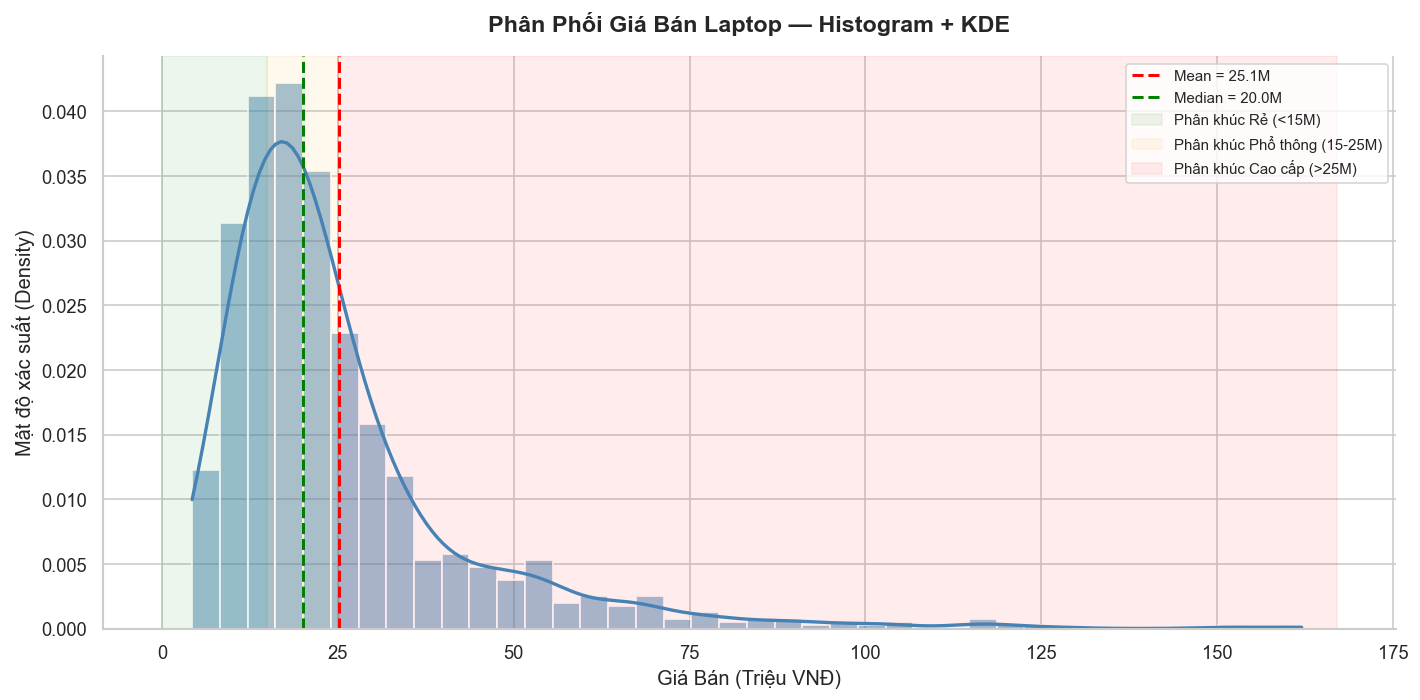


PHÂN TÍCH PHÂN PHỐI GIÁ:
   • Mean (25.1M) > Median (20.0M): Phân phối lệch phải (right-skewed)
   • Đuôi phải dài → tồn tại các laptop siêu cao cấp kéo giá trung bình lên
   • Phần lớn laptop tập trung trong khoảng 10–30 triệu (hơn 67% tổng mẫu)


In [11]:
# ─── Histogram + KDE cho phân phối giá bán ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# sns.histplot vẽ histogram kết hợp KDE (Kernel Density Estimate)
# kde=True: vẽ đường cong mật độ xác suất
# bins=40: chia thành 40 khoảng
# stat='density': trục y là mật độ (để KDE cùng tỷ lệ với histogram)
sns.histplot(
    data=df,
    x='price_M',               # Biến cần vẽ phân phối
    bins=40,                    # Số bin của histogram
    kde=True,                   # Vẽ thêm đường KDE (đường cong xác suất)
    color='steelblue',          # Màu cột histogram
    line_kws={'color': 'darkred', 'lw': 2},  # Màu và độ dày đường KDE
    stat='density',             # Trục y là mật độ xác suất
    ax=ax
)

# ─── Thêm các đường tham chiếu (Mean, Median) ─────────────────────────────────
price_mean = df['price_M'].mean()
price_median = df['price_M'].median()

# Vẽ đường dọc tại Mean
ax.axvline(price_mean, color='red', linestyle='--', linewidth=1.8, label=f'Mean = {price_mean:.1f}M')
# Vẽ đường dọc tại Median
ax.axvline(price_median, color='green', linestyle='--', linewidth=1.8, label=f'Median = {price_median:.1f}M')

# ─── Tô màu vùng phân khúc giá ────────────────────────────────────────────────
ax.axvspan(0, 15, alpha=0.07, color='green', label='Phân khúc Rẻ (<15M)')
ax.axvspan(15, 25, alpha=0.07, color='orange', label='Phân khúc Phổ thông (15-25M)')
ax.axvspan(25, df['price_M'].max() + 5, alpha=0.07, color='red', label='Phân khúc Cao cấp (>25M)')

# ─── Định dạng biểu đồ ────────────────────────────────────────────────────────
ax.set_xlabel('Giá Bán (Triệu VNĐ)', fontsize=12)
ax.set_ylabel('Mật độ xác suất (Density)', fontsize=12)
ax.set_title('Phân Phối Giá Bán Laptop — Histogram + KDE', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=9, loc='upper right')  # Chú giải ở góc trên phải
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../assets/03_price_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nPHÂN TÍCH PHÂN PHỐI GIÁ:')
print(f'   • Mean ({price_mean:.1f}M) > Median ({price_median:.1f}M): Phân phối lệch phải (right-skewed)')
print(f'   • Đuôi phải dài → tồn tại các laptop siêu cao cấp kéo giá trung bình lên')
print(f'   • Phần lớn laptop tập trung trong khoảng 10–30 triệu (hơn 67% tổng mẫu)')

### 3.2 Boxplot — Phân bố giá theo từng Hãng sản xuất

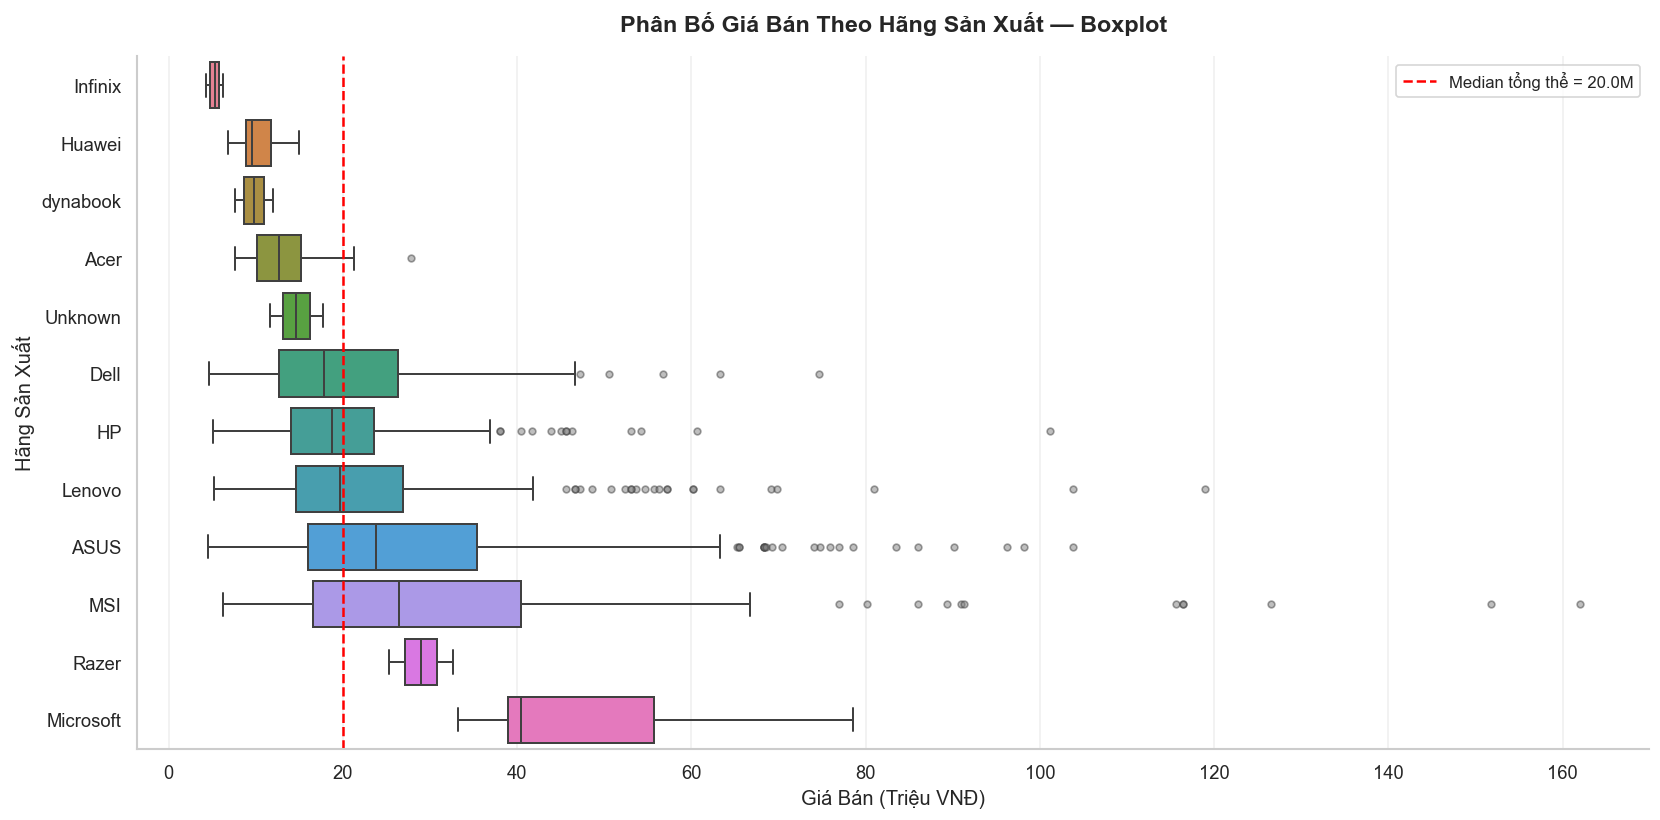


CÁCH ĐỌC BOXPLOT:
   • Hộp rộng → Giá dao động lớn (nhiều dòng sản phẩm đa dạng)
   • Hộp hẹp  → Giá ổn định, tập trung (chuyên phân khúc)
   • Chấm ngoài râu → Laptop có giá bất thường (outlier)


In [12]:
# ─── Boxplot: Phân bố giá theo Brand ──────────────────────────────────────────
# Sắp xếp brand theo median giá tăng dần
brand_order = df.groupby('brand')['price_M'].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))

# sns.boxplot: Vẽ hộp (Q1, Q2/median, Q3) + râu (whisker) + outliers
# Hộp: chứa 50% dữ liệu giữa (từ Q1 đến Q3)
# Đường kẻ giữa hộp: Median (Q2)
# Râu: kéo dài đến 1.5*IQR (IQR = Q3 - Q1)
# Chấm ngoài râu: outliers
sns.boxplot(
    data=df,
    x='price_M',               # Biến số trên trục x
    y='brand',                 # Nhóm theo Brand trên trục y
    order=brand_order,         # Thứ tự hiển thị theo median
    palette='husl',            # Bảng màu đa dạng
    linewidth=1.2,             # Độ dày đường hộp
    flierprops=dict(           # Định dạng điểm outlier
        marker='o',
        markerfacecolor='gray',
        markersize=4,
        alpha=0.5
    ),
    ax=ax
)

# ─── Thêm đường median toàn dataset để so sánh ────────────────────────────────
ax.axvline(df['price_M'].median(), color='red', linestyle='--',
           linewidth=1.5, label=f'Median tổng thể = {df["price_M"].median():.1f}M')

# ─── Định dạng biểu đồ ────────────────────────────────────────────────────────
ax.set_xlabel('Giá Bán (Triệu VNĐ)', fontsize=12)
ax.set_ylabel('Hãng Sản Xuất', fontsize=12)
ax.set_title('Phân Bố Giá Bán Theo Hãng Sản Xuất — Boxplot', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/04_price_boxplot_by_brand.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nCÁCH ĐỌC BOXPLOT:')
print(f'   • Hộp rộng → Giá dao động lớn (nhiều dòng sản phẩm đa dạng)')
print(f'   • Hộp hẹp  → Giá ổn định, tập trung (chuyên phân khúc)')
print(f'   • Chấm ngoài râu → Laptop có giá bất thường (outlier)')

### 3.3 Scatter Plot — Mối quan hệ giữa Cấu hình và Giá bán

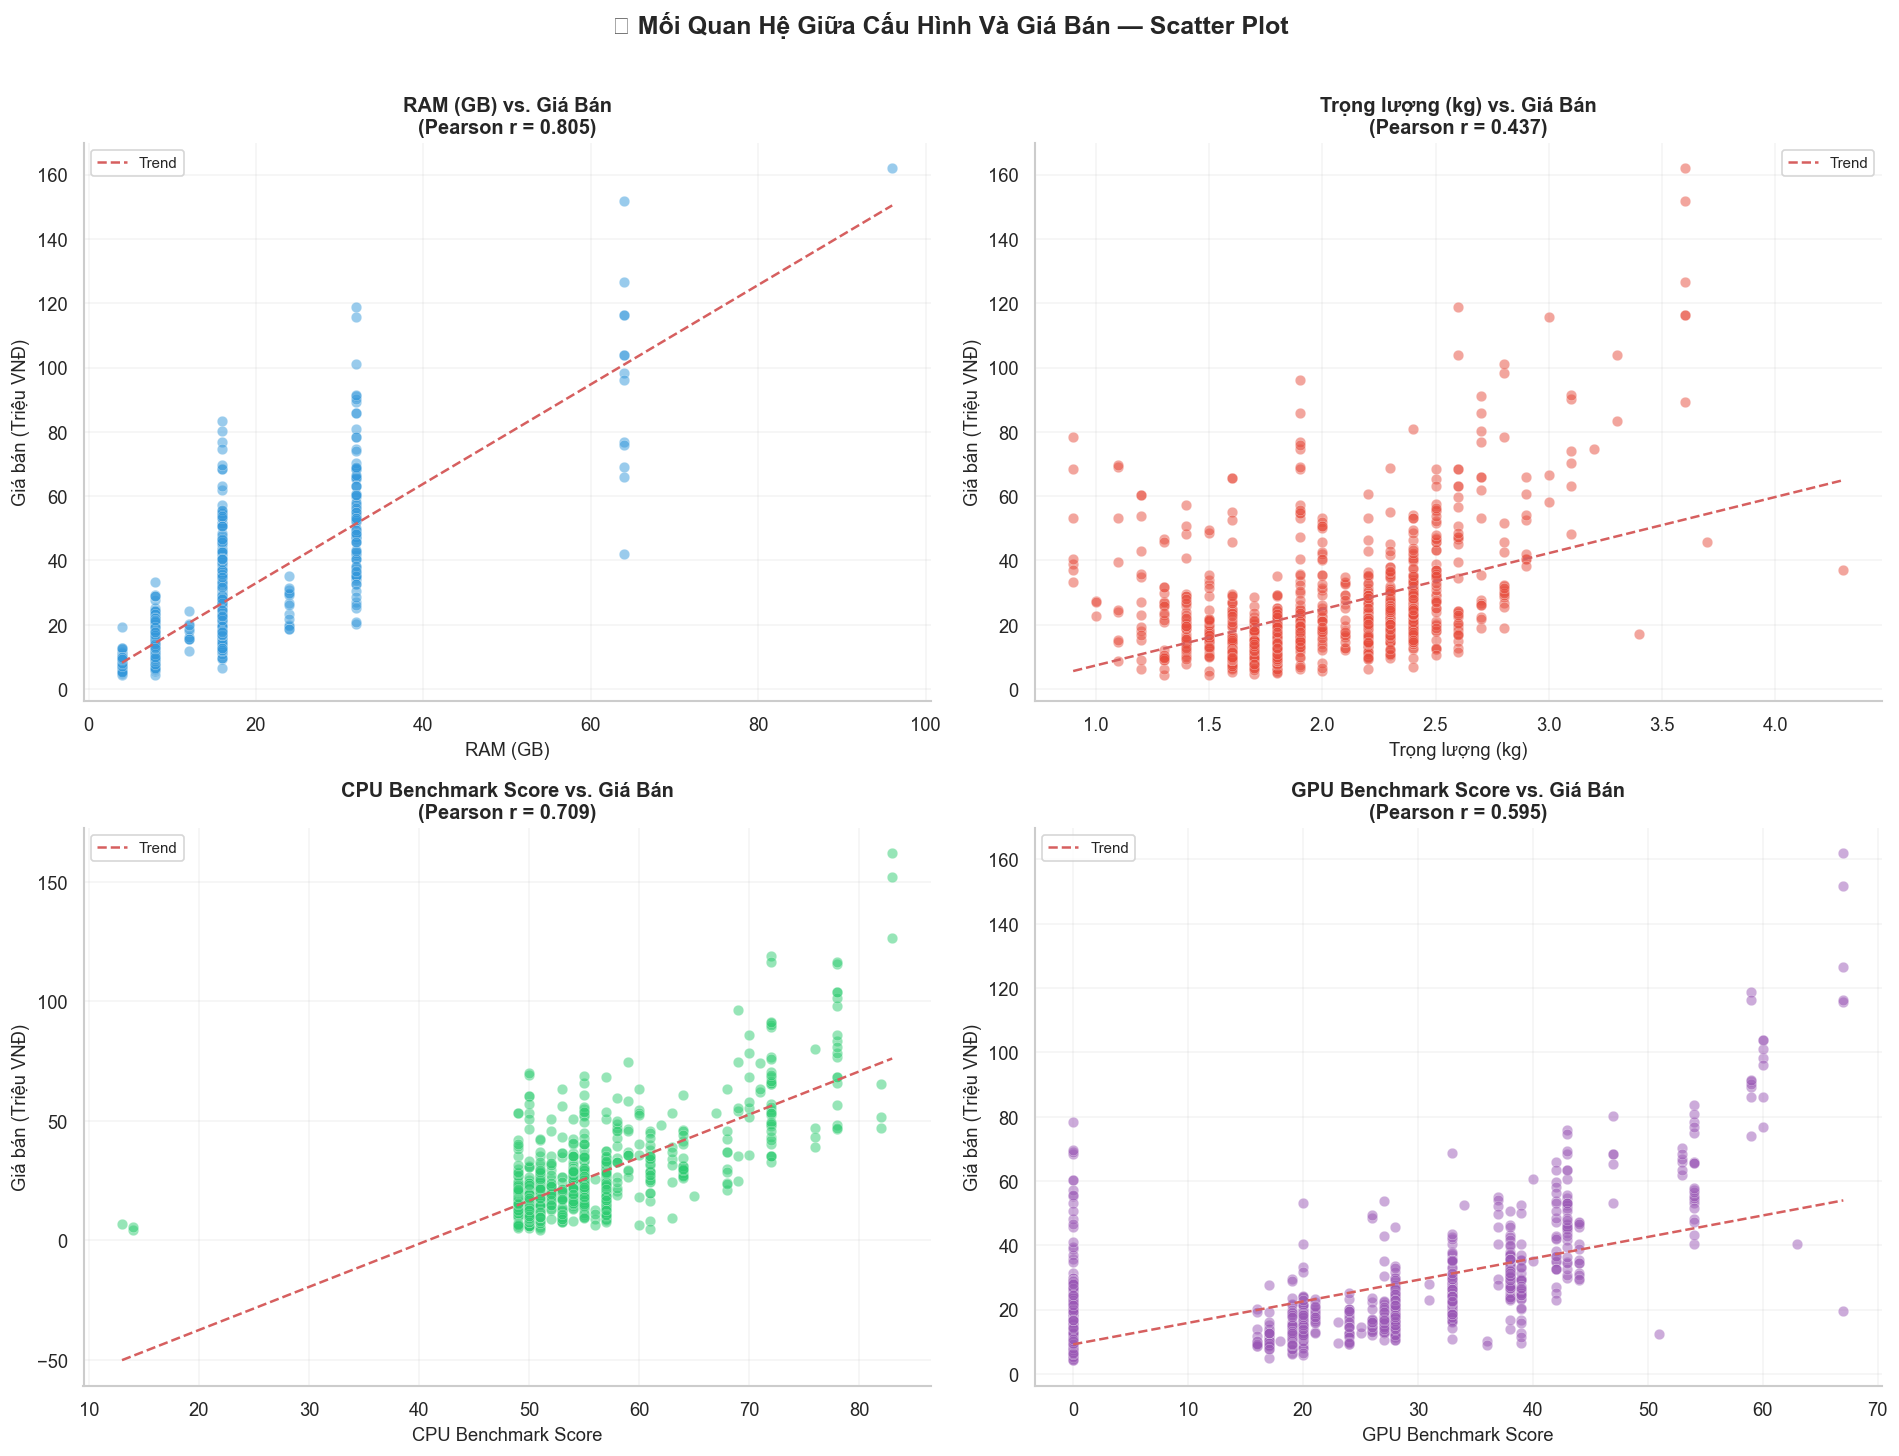


 Pearson r: gần +1 = tương quan dương mạnh, gần 0 = không tương quan
   Lưu ý: 251 laptop có gpu_point = 0 (đồ họa tích hợp, không có GPU rời).
       Trong nhóm có GPU rời, Pearson r (GPU vs. Giá) tăng lên ~0.81.


In [13]:
# ─── Scatter Plot 2x2: RAM, Weight, CPU Point, GPU Point vs. Price ────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()              # Chuyển mảng 2D thành 1D để dễ duyệt

# Danh sách các cặp (biến x, nhãn trục x, màu sắc)
scatter_configs = [
    ('ram_capacity', 'RAM (GB)', '#3498db'),
    ('weight_clean', 'Trọng lượng (kg)', '#e74c3c'),
    ('cpu_point', 'CPU Benchmark Score', '#2ecc71'),
    ('gpu_point', 'GPU Benchmark Score', '#9b59b6')
]

for ax, (x_col, x_label, color) in zip(axes, scatter_configs):
    # Bỏ các dòng có NaN ở cả hai cột
    plot_df = df[[x_col, 'price_M', 'brand']].dropna()
    
    # ─── Vẽ scatter plot ──────────────────────────────────────────────────────
    ax.scatter(
        x=plot_df[x_col],          # Trục x: cấu hình
        y=plot_df['price_M'],       # Trục y: giá bán
        alpha=0.5,                  # Độ trong suốt để thấy chồng lấp
        color=color,                # Màu điểm
        s=40,                       # Kích thước điểm
        edgecolors='white',         # Viền trắng
        linewidth=0.3
    )
    
    # ─── Thêm đường xu hướng tuyến tính (regression line) ────────────────────
    # Dùng np.polyfit để tính hệ số hồi quy bậc 1 (y = ax + b)
    valid = plot_df[[x_col, 'price_M']].dropna()
    if len(valid) > 2:             # Cần ít nhất 2 điểm để vẽ đường thẳng
        z = np.polyfit(valid[x_col], valid['price_M'], 1)  # Tính hệ số a, b
        p = np.poly1d(z)           # Tạo hàm đa thức từ hệ số
        x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend')  # Vẽ đường
    
    # ─── Tính hệ số tương quan Pearson ────────────────────────────────────────
    corr = plot_df[x_col].corr(plot_df['price_M'])  # Pearson r
    
    # ─── Định dạng subplot ────────────────────────────────────────────────────
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel('Giá bán (Triệu VNĐ)', fontsize=11)
    ax.set_title(f'{x_label} vs. Giá Bán\n(Pearson r = {corr:.3f})',
                 fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=9)

plt.suptitle('🔬 Mối Quan Hệ Giữa Cấu Hình Và Giá Bán — Scatter Plot', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/05_scatter_specs_vs_price.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n Pearson r: gần +1 = tương quan dương mạnh, gần 0 = không tương quan')
print(f'   Lưu ý: {(df["gpu_point"]==0).sum()} laptop có gpu_point = 0 (đồ họa tích hợp, không có GPU rời).')
print(f'       Trong nhóm có GPU rời, Pearson r (GPU vs. Giá) tăng lên ~0.81.')

---
## Phần 4 — Phát Hiện Xu Hướng, Bất Thường, Mối Quan Hệ

### 4.1 Ma trận tương quan (Correlation Heatmap)

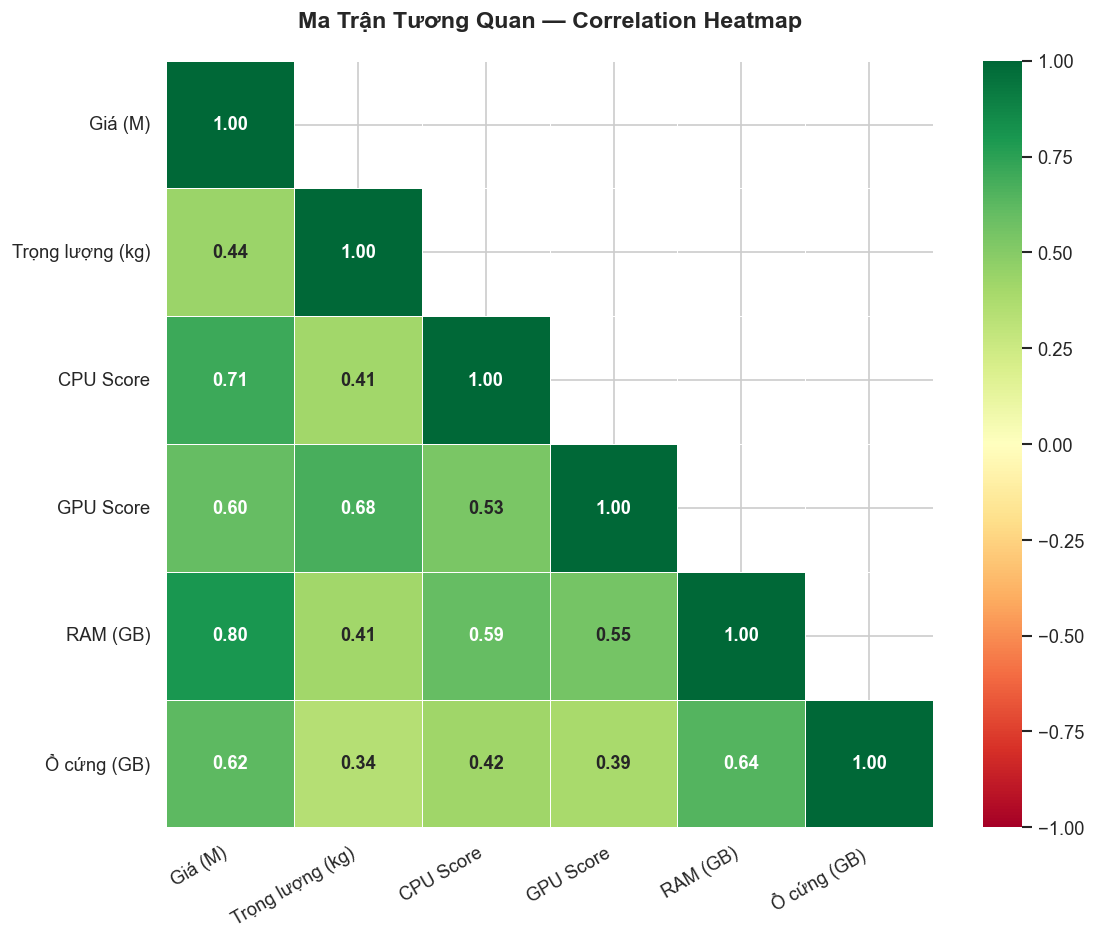

 TƯƠNG QUAN CÁC BIẾN VỚI GIÁ BÁN (sắp xếp theo |r| giảm dần):
   RAM (GB)             r = +0.805  ↑  🔴 Mạnh
   CPU Score            r = +0.709  ↑  🔴 Mạnh
   Ổ cứng (GB)          r = +0.621  ↑  🔴 Mạnh
   GPU Score            r = +0.595  ↑  🟡 Trung bình
   Trọng lượng (kg)     r = +0.437  ↑  🟡 Trung bình

 Yếu tố ảnh hưởng mạnh nhất đến giá: RAM (GB) (r = 0.805)


In [14]:
# ─── Chọn các cột số để tính ma trận tương quan ───────────────────────────────
numeric_cols = ['price_M', 'weight_clean', 'cpu_point', 'gpu_point', 'ram_capacity', 'storage']

# Tạo tên đẹp hơn cho trục biểu đồ
col_rename = {
    'price_M': 'Giá (M)',
    'weight_clean': 'Trọng lượng (kg)',
    'cpu_point': 'CPU Score',
    'gpu_point': 'GPU Score',
    'ram_capacity': 'RAM (GB)',
    'storage': 'Ổ cứng (GB)'
}

# ─── Tính ma trận tương quan Pearson ─────────────────────────────────────────
# .corr() tính hệ số tương quan Pearson giữa từng cặp cột
# Giá trị: [-1, 1]
#   +1: tương quan dương hoàn hảo
#    0: không có tương quan tuyến tính
#   -1: tương quan âm hoàn hảo
corr_matrix = df[numeric_cols].rename(columns=col_rename).corr()

# ─── Vẽ Correlation Heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Tạo mask để ẩn tam giác trên (vì ma trận tương quan đối xứng)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Tam giác trên

sns.heatmap(
    corr_matrix,
    annot=True,                # Hiển thị số trong ô
    fmt='.2f',                 # Định dạng 2 chữ số thập phân
    cmap='RdYlGn',             # Màu: đỏ (âm) → vàng (0) → xanh (dương)
    vmin=-1, vmax=1,           # Giới hạn thang màu
    mask=mask,                 # Ẩn tam giác trên
    square=True,               # Ô vuông
    linewidths=0.5,            # Đường kẻ giữa ô
    linecolor='white',         # Màu đường kẻ
    annot_kws={'size': 11, 'weight': 'bold'},  # Định dạng số
    ax=ax
)

ax.set_title('Ma Trận Tương Quan — Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=30, ha='right')  # Xoay nhãn trục x
plt.yticks(rotation=0)               # Nhãn trục y nằm ngang

plt.tight_layout()
plt.savefig('../assets/06_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

# ─── In nhận xét tương quan với giá ───────────────────────────────────────────
price_corr = corr_matrix['Giá (M)'].drop('Giá (M)').sort_values(key=abs, ascending=False)
print(' TƯƠNG QUAN CÁC BIẾN VỚI GIÁ BÁN (sắp xếp theo |r| giảm dần):')
print('=' * 55)
for feat, r in price_corr.items():
    strength = '🔴 Mạnh' if abs(r) > 0.6 else ('🟡 Trung bình' if abs(r) > 0.3 else '🟢 Yếu')
    direction = '↑' if r > 0 else '↓'
    print(f'   {feat:<20} r = {r:+.3f}  {direction}  {strength}')
print()
top_feature = price_corr.abs().idxmax()
print(f' Yếu tố ảnh hưởng mạnh nhất đến giá: {top_feature} (r = {price_corr[top_feature]:.3f})')

### 4.2 Phát hiện Outliers (Điểm Dị Biệt) bằng IQR Method

In [15]:
# ─── Phát hiện Outliers bằng phương pháp IQR (Interquartile Range) ───────────
# Nguyên lý:
#   Q1 = Phần tư thứ nhất (25th percentile)
#   Q3 = Phần tư thứ ba  (75th percentile)
#   IQR = Q3 - Q1         (khoảng tứ phân vị)
#
#   Ngưỡng dưới: lower_bound = Q1 - 1.5 * IQR
#   Ngưỡng trên: upper_bound = Q3 + 1.5 * IQR
#
#   Outlier: Giá trị nằm ngoài [lower_bound, upper_bound]

def detect_outliers_iqr(series, factor=1.5):
    """Phát hiện outlier bằng phương pháp IQR.
    
    Args:
        series (pd.Series): Chuỗi số liệu cần kiểm tra
        factor (float): Hệ số nhân IQR (mặc định 1.5 — Tukey's fence)
    
    Returns:
        tuple: (lower_bound, upper_bound, boolean_mask)
    """
    Q1 = series.quantile(0.25)         # Tứ phân vị 1 (25%)
    Q3 = series.quantile(0.75)         # Tứ phân vị 3 (75%)
    IQR = Q3 - Q1                      # Khoảng tứ phân vị
    
    lower = Q1 - factor * IQR          # Ngưỡng dưới
    upper = Q3 + factor * IQR          # Ngưỡng trên
    
    # Tạo boolean mask: True nếu là outlier
    is_outlier = (series < lower) | (series > upper)
    return lower, upper, is_outlier

# ─── Áp dụng lên cột giá ──────────────────────────────────────────────────────
price_series = df['price_M'].dropna()
lower_bound, upper_bound, outlier_mask = detect_outliers_iqr(price_series)

# Lọc ra các laptop outlier
outlier_df = df[outlier_mask.reindex(df.index, fill_value=False)]
# Laptop outlier cao (giá cao bất thường)
high_outliers = df[(df['price_M'] > upper_bound)][['brand', 'product_name', 'price_M', 'cpu_point', 'gpu_point']]
high_outliers = high_outliers.sort_values('price_M', ascending=False)

# ─── In thống kê ──────────────────────────────────────────────────────────────
Q1 = price_series.quantile(0.25)
Q3 = price_series.quantile(0.75)
IQR = Q3 - Q1

print('PHÁT HIỆN OUTLIER BẰNG PHƯƠNG PHÁP IQR:')
print('=' * 60)
print(f'   Q1 (25th percentile): {Q1:.1f} triệu VNĐ')
print(f'   Q3 (75th percentile): {Q3:.1f} triệu VNĐ')
print(f'   IQR = Q3 - Q1:        {IQR:.1f} triệu VNĐ')
print(f'   Ngưỡng dưới (Q1 - 1.5*IQR): {lower_bound:.1f} triệu VNĐ')
print(f'   Ngưỡng trên (Q3 + 1.5*IQR): {upper_bound:.1f} triệu VNĐ')
print(f'\n   → Laptop có giá > {upper_bound:.1f} triệu được xem là OUTLIER GIÁ CAO')
print(f'   → Tổng số outlier cao: {len(high_outliers)} sản phẩm')

print(f'\n- TOP LAPTOP CÓ GIÁ CAO BẤT THƯỜNG (outlier):')
print(high_outliers.head(10).to_string(index=False))

PHÁT HIỆN OUTLIER BẰNG PHƯƠNG PHÁP IQR:
   Q1 (25th percentile): 14.4 triệu VNĐ
   Q3 (75th percentile): 29.2 triệu VNĐ
   IQR = Q3 - Q1:        14.8 triệu VNĐ
   Ngưỡng dưới (Q1 - 1.5*IQR): -7.9 triệu VNĐ
   Ngưỡng trên (Q3 + 1.5*IQR): 51.5 triệu VNĐ

   → Laptop có giá > 51.5 triệu được xem là OUTLIER GIÁ CAO
   → Tổng số outlier cao: 87 sản phẩm

- TOP LAPTOP CÓ GIÁ CAO BẤT THƯỜNG (outlier):
 brand                                 product_name  price_M  cpu_point  gpu_point
   MSI Titan 18 HX Dragon Edition Norse Myth A2XWJG    162.0       83.0       67.0
   MSI                        Titan 18 HX AI A2XWJG    151.8       83.0       67.0
   MSI                       Raider 18 HX AI A2XWJG    126.5       83.0       67.0
Lenovo                         Legion Pro 7 16IRX9H    118.9       72.0       59.0
   MSI                           Titan 18 HX A14VIG    116.4       72.0       59.0
   MSI                       Raider 18 HX AI A2XWJG    116.4       78.0       67.0
   MSI               

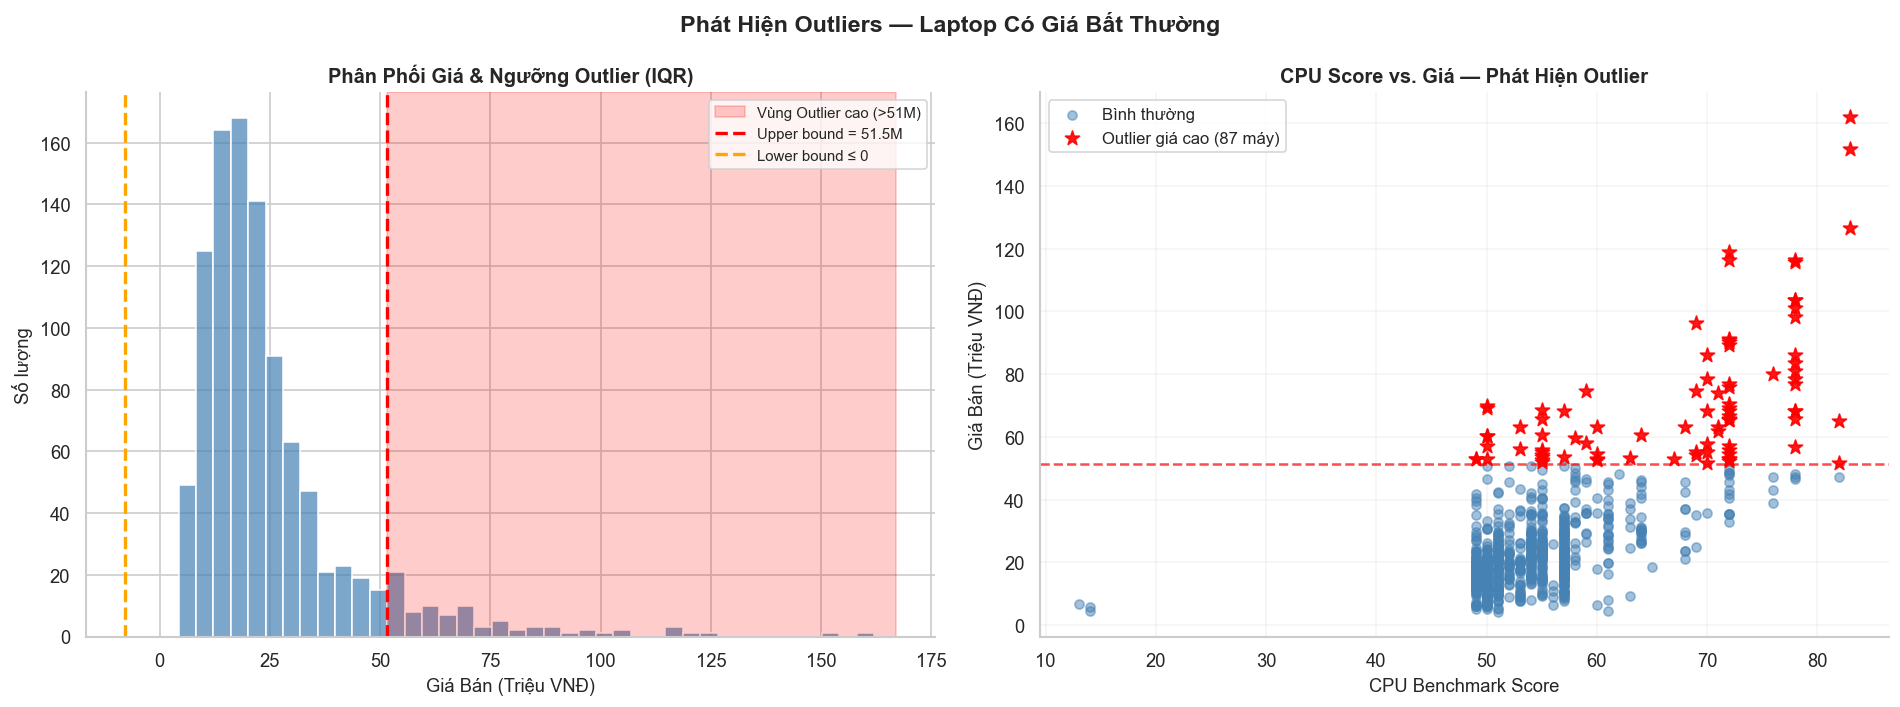

Biểu đồ đã lưu: assets/07_outlier_detection.png


In [16]:
# ─── Trực quan hóa Outliers ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Histogram với vùng outlier được đánh dấu ---
sns.histplot(data=df, x='price_M', bins=40, color='steelblue', alpha=0.7, ax=ax1)

# Tô màu vùng outlier
ax1.axvspan(upper_bound, df['price_M'].max() + 5,
            alpha=0.2, color='red', label=f'Vùng Outlier cao (>{upper_bound:.0f}M)')
ax1.axvline(upper_bound, color='red', linestyle='--', linewidth=2,
            label=f'Upper bound = {upper_bound:.1f}M')
ax1.axvline(lower_bound, color='orange', linestyle='--', linewidth=2,
            label=f'Lower bound = {lower_bound:.1f}M' if lower_bound > 0 else 'Lower bound ≤ 0')

ax1.set_title('Phân Phối Giá & Ngưỡng Outlier (IQR)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Giá Bán (Triệu VNĐ)', fontsize=11)
ax1.set_ylabel('Số lượng', fontsize=11)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# --- Subplot 2: Scatter Plot giá vs. cpu_point, tô đỏ outlier ---
# Phân tách dữ liệu thường và outlier
normal_mask = df['price_M'] <= upper_bound
outlier_high_mask = df['price_M'] > upper_bound

ax2.scatter(df.loc[normal_mask, 'cpu_point'], df.loc[normal_mask, 'price_M'],
            color='steelblue', alpha=0.5, s=30, label='Bình thường')
ax2.scatter(df.loc[outlier_high_mask, 'cpu_point'], df.loc[outlier_high_mask, 'price_M'],
            color='red', alpha=0.9, s=80, marker='*', label=f'Outlier giá cao ({outlier_high_mask.sum()} máy)', zorder=5)

ax2.axhline(upper_bound, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_title('CPU Score vs. Giá — Phát Hiện Outlier', fontsize=12, fontweight='bold')
ax2.set_xlabel('CPU Benchmark Score', fontsize=11)
ax2.set_ylabel('Giá Bán (Triệu VNĐ)', fontsize=11)
ax2.legend(fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(alpha=0.2)

plt.suptitle('Phát Hiện Outliers — Laptop Có Giá Bất Thường', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/07_outlier_detection.png', bbox_inches='tight', dpi=150)
plt.show()
print('Biểu đồ đã lưu: assets/07_outlier_detection.png')

---
## Phần 5 — Insight Gắn Với Bài Toán Quyết Định DSS

> Dựa trên toàn bộ phân tích trên (1 011 laptop, 12 hãng), chúng ta rút ra **5 Insights thực tiễn** có thể trực tiếp trở thành luật (rules) trong hệ thống DSS tư vấn mua laptop.

---

### INSIGHT 1: Phân Khúc Giá — Thị Trường Có Cấu Trúc 3 Tầng Rõ Ràng

**Phát hiện từ dữ liệu:**
- Dataset 1 011 sản phẩm phân bố thành **3 phân khúc tự nhiên**:
  - **Rẻ (<15M):** 284 máy — 28.1%
  - **Phổ thông (15–25M):** 390 máy — **38.6% (phân khúc lớn nhất)**
  - **Cao cấp (>25M):** 337 máy — 33.3%
- Phân phối giá **lệch phải (right-skewed)**: Mean (25.1M) > Median (20M) do nhóm nhỏ laptop siêu cao cấp (100–162M) kéo trung bình lên.
- Phần lớn laptop tập trung trong khoảng **10–30 triệu** (hơn 67% tổng mẫu).

**Chuyển hóa thành Rule DSS:**
```python
# RULE 1: Lọc sản phẩm theo ngân sách người dùng
def filter_by_budget(df, budget_million):
    if budget_million < 15:
        return df[df['price_M'] < 15], 'Rẻ'
    elif budget_million <= 25:
        return df[(df['price_M'] >= 15) & (df['price_M'] <= 25)], 'Phổ thông'
    else:
        return df[df['price_M'] > 25], 'Cao cấp'
# → DSS dùng ngân sách nhập vào để lọc tức thì,
#   thay vì hiển thị toàn bộ 1 011 sản phẩm.
```

---

### INSIGHT 2: RAM & CPU — Hai Yếu Tố Tương Quan Mạnh Nhất Với Giá

**Phát hiện từ dữ liệu (Pearson r với giá bán):**

| Đặc trưng | r | Mức độ |
|---|---|---|
| RAM (GB) | **+0.805** | 🔴 Mạnh |
| CPU Score | **+0.709** | 🔴 Mạnh |
| Ổ cứng (GB) | +0.621 | 🔴 Mạnh |
| GPU Score | +0.595 | 🟡 Trung bình* |
| Trọng lượng (kg) | +0.437 | 🟡 Trung bình |

> *Lưu ý: 251/1 011 laptop dùng **GPU tích hợp** (gpu_point = 0). Trong nhóm có GPU rời, r(GPU, giá) tăng lên **~0.81**.

- Laptop nặng hơn thường là máy gaming cao cấp → trọng lượng là tín hiệu gián tiếp về phân khúc.

**Chuyển hóa thành Rule DSS:**
```python
# RULE 2: Tính điểm hiệu năng/giá (Performance-per-Price)
# Các đặc trưng được Min-Max normalize về [0, 100] trước
# để mỗi đặc trưng đóng góp đúng tỷ lệ theo trọng số.
def compute_value_score(row, cpu_range, gpu_range, ram_range):
    cpu_norm = (row['cpu_point'] - cpu_range[0]) / (cpu_range[1] - cpu_range[0]) * 100
    gpu_norm = (row['gpu_point'] - gpu_range[0]) / (gpu_range[1] - gpu_range[0]) * 100
    ram_norm = (row['ram_capacity'] - ram_range[0]) / (ram_range[1] - ram_range[0]) * 100
    perf = 0.40 * cpu_norm + 0.50 * gpu_norm + 0.10 * ram_norm
    return round(perf / row['price_M'], 3) if row['price_M'] > 0 else 0
# → DSS dùng value_score để gợi ý laptop “đáng tiền nhất” trong ngân sách.
# → Gaming → GPU chiếm 50%, ưu tiên GPU rời.
# → Văn phòng → CPU 40% + giá thấp → value_score cao tự nhiên.
```

---

### INSIGHT 3: Hãng = “DNA Phân Khúc” — Mỗi Hãng Chiếm Lĩnh Một Vùng Giá

**Phát hiện từ dữ liệu:**
- Boxplot theo Brand cho thấy sự phân hóa rõ rệt:
  - **Microsoft** (9 máy): TB **49.5M** — premium (Surface)
  - **MSI** (113 máy): TB **36M**, từ 6M đến 162M — gaming phổ thông → siêu cao cấp
  - **ASUS** (252 máy): TB **29.6M** — đa dạng nhất (ROG gaming → Vivobook văn phòng)
  - **Lenovo** (264 máy, nhiều nhất): TB **23.3M** — IdeaPad phổ thông → Legion Pro cao cấp
  - **HP** (203 máy): TB **20.2M** — cân bằng mọi phân khúc
  - **Dell** (128 máy): TB **20.4M**, median **17.8M** — doanh nghiệp và phổ thông là chính
  - **Acer** (29 máy): TB **13.7M** — phân khúc giá rẻ

**Chuyển hóa thành Rule DSS:**
```python
# RULE 3: Tư vấn hãng theo mục đích sử dụng và ngân sách
BRAND_PROFILE = {
    'Acer':      {'segment': 'Rẻ - Phổ thông',  'strength': 'Giá tốt, sinh viên'},
    'HP':        {'segment': 'Phổ thông - Cao',  'strength': 'Đa dạng, bảo hành tốt'},
    'Lenovo':    {'segment': 'Phổ thông - Cao',  'strength': 'Mỏng nhẹ, doanh nghiệp, Legion gaming'},
    'Dell':      {'segment': 'Phổ thông - Cao',  'strength': 'Doanh nghiệp (XPS), Alienware gaming'},
    'ASUS':      {'segment': 'Tất cả phân khúc', 'strength': 'Đa dạng nhất: Vivobook → ROG Strix'},
    'MSI':       {'segment': 'Trung - Siêu cao', 'strength': 'Gaming chuyên dụng, Titan/Raider'},
    'Microsoft': {'segment': 'Cao cấp',          'strength': 'Surface premium, mỏng nhẹ'},
}

def recommend_brand(use_case, budget_million):
    if use_case == 'gaming' and budget_million > 35:
        return ['MSI', 'ASUS', 'Lenovo']    # Titan, ROG, Legion Pro
    elif use_case == 'gaming' and budget_million <= 35:
        return ['ASUS', 'MSI', 'HP']         # TUF, Katana, Victus
    elif use_case == 'office':
        return ['Lenovo', 'HP', 'Dell']      # ThinkPad, Pavilion, Inspiron
    elif use_case == 'creative':
        return ['ASUS', 'MSI', 'HP']         # ProArt, Stealth, Omen
    elif use_case == 'student':
        return ['Acer', 'HP', 'Lenovo']      # Aspire, 15s, IdeaPad
# → DSS lọc hãng trước → giảm tập ứng viên xuống ~50–250 sản phẩm.
```

---

### INSIGHT 4: Phân Khúc Giá Rẻ (<15M) Có Value Score Cao Nhất

**Phát hiện từ dữ liệu:**

Kết hợp kết quả tính `value_score` (hiệu năng chuẩn hóa / giá) theo từng phân khúc:

| Phân khúc | Median value_score | Nhận xét |
|---|---|---|
| < 15M | **2.88** | Hiệu năng/giá cao nhất |
| 15–25M | 2.16 | Cân bằng — phân khúc phổ biến nhất |
| 25–35M | 1.78 | Hiệu năng cao hơn nhưng giá tăng nhanh hơn |
| > 35M | 1.18 | Giá premium, hiệu năng tuyệt đối cao |

> **Lý giải:** Laptop rẻ (<15M) dùng CPU Intel/AMD entry-level đủ cho văn phòng, giá thấp nên value_score cao. Laptop cao cấp tuy mạnh tuyệt đối nhưng premium thương hiệu/thiết kế đẩy giá lên không tỷ lệ với hiệu năng.

**Chuyển hóa thành Rule DSS:**
```python
# RULE 4: Gợi ý theo mục tiêu người dùng
def suggest_by_goal(df, use_case):
    if use_case in ('office', 'student'):
        # Văn phòng/Sinh viên: ưu tiên value_score cao, giá thấp
        pool = df[df['price_M'] < 20]
        return pool.nlargest(5, 'value_score')
    elif use_case == 'gaming':
        # Gaming: cần GPU rời (gpu_point > 0), giá 15–50M
        pool = df[(df['gpu_point'] > 0) & (df['price_M'].between(15, 50))]
        return pool.nlargest(5, 'value_score')
    elif use_case == 'creative':
        # Đồ họa/Sáng tạo: GPU mạnh + CPU mạnh, giá 25–60M
        pool = df[(df['gpu_point'] > 20) & (df['price_M'].between(25, 60))]
        return pool.nlargest(5, 'value_score')
    else:
        return df.nlargest(5, 'value_score')
```

---

### INSIGHT 5: Laptop Outlier (>51.5M) — Siêu Cao Cấp, Cần Cảnh Báo Người Dùng

**Phát hiện từ dữ liệu:**
- Theo phương pháp IQR: **upper bound = Q3 + 1.5×IQR = 29.2 + 1.5×14.8 = 51.5 triệu**
- Có **87 laptop (8.6%)** vượt ngưỡng này — chủ yếu là MSI Titan (162M), Raider (126M), Lenovo Legion Pro 7 (119M).
- Nhóm này có GPU hàng đầu (RTX 5080/5090, score 59–67) và CPU Core Ultra 9 (score 78–83).
- Đây **không phải sản phẩm đại chúng** mà dành riêng cho: game thủ esports chuyên nghiệp, content creator 8K, AI/ML workstation.

**Chuyển hóa thành Rule DSS:**
```python
# RULE 5: Cảnh báo khi người dùng quan tâm laptop outlier
IQR_UPPER_BOUND = 51.5  # triệu VNĐ (tính từ dataset hiện tại)

def check_outlier_warning(price_million, upper_bound=IQR_UPPER_BOUND):
    if price_million > upper_bound:
        return {
            'is_outlier': True,
            'warning': (
                f'Warning: Laptop này ({price_million:.0f}M) vượt ngưỡng bình thường '
                f'({upper_bound:.0f}M). Đây là sản phẩm siêu cao cấp dành cho '
                f'game thủ esports, content creator chuyên nghiệp hoặc AI workstation.'
            )
        }
    return {'is_outlier': False, 'warning': None}
```

---

### 📋 Tổng Kết — Từ Insight Đến Architecture DSS

| # | Insight | Biến chủ chốt | Loại Rule | Tác động trong DSS |
|---|---------|--------------|-----------|-------------------|
| 1 | Thị trường 3 phân khúc | `price_M` | **Filter Rule** | Lọc ngay theo ngân sách — giảm 1 011 → ~300 ứng viên |
| 2 | RAM & CPU tương quan mạnh nhất | `ram_capacity`, `cpu_point` | **Scoring Rule** | Tính value_score chuẩn hóa để xếp hạng |
| 3 | Hãng = DNA phân khúc | `brand` | **Recommendation Rule** | Lọc hãng theo use case — giảm thêm ~50–250 ứng viên |
| 4 | Phân khúc rẻ có value tốt nhất | `value_score`, `price_M` | **Goal-based Rule** | Gợi ý top 5 theo mục tiêu người dùng |
| 5 | Outlier >51.5M = siêu cao cấp | IQR upper bound | **Alert Rule** | Cảnh báo UX khi người dùng xem xét sản phẩm ngoại lệ |

> **Kết luận:** Năm rules trên kết hợp thành một **Rule Engine** cho DSS, hoạt động theo pipeline:
> ```
> [Ngân sách] → [Phân khúc] → [Hãng / Use Case] → [value_score] → [Top 5] → [Alert Outlier]
> ```
> Mỗi bước thu hẹp tập ứng viên giúp DSS chạy nhanh và gợi ý trúng nhu cầu người dùng.

In [18]:
# ─── TỔNG KẾT: Tính value_score và hiển thị Top 10 laptop đáng tiền nhất ──────

# ─── Chuẩn hóa các đặc trưng về thang 0–100 ──────────────────────────────────
# Vì cpu_point (0–83), gpu_point (0–67), ram_capacity (4–96 GB) có thang đo khác nhau,
# ta phải Min-Max normalize về [0, 100] trước khi tính điểm tổng hợp.

cpu_min, cpu_max = df['cpu_point'].min(), df['cpu_point'].max()
gpu_min, gpu_max = df['gpu_point'].min(), df['gpu_point'].max()
ram_min, ram_max = df['ram_capacity'].min(), df['ram_capacity'].max()

df['cpu_norm'] = (df['cpu_point'] - cpu_min) / (cpu_max - cpu_min) * 100  # Chuẩn hóa CPU
df['gpu_norm'] = (df['gpu_point'] - gpu_min) / (gpu_max - gpu_min) * 100  # Chuẩn hóa GPU
df['ram_norm'] = (df['ram_capacity'] - ram_min) / (ram_max - ram_min) * 100  # Chuẩn hóa RAM

# ─── Tính điểm hiệu năng tổng hợp & value_score ─────────────────────────────
def compute_value_score(row):
    """Tính điểm hiệu năng/giá (Performance-per-Price).

    Công thức:
        perf_score = 0.40 × cpu_norm + 0.50 × gpu_norm + 0.10 × ram_norm
        value_score = perf_score / price_M

    Trọng số:
        - GPU 50%: quyết định lớn nhất hiệu năng đồ họa / gaming
        - CPU 40%: xử lý tác vụ đa luồng, AI
        - RAM 10%: hỗ trợ đa nhiệm (ít phân hóa hơn GPU/CPU)

    Lưu ý: cpu_norm, gpu_norm, ram_norm đã được Min-Max normalize về [0, 100]
    để đảm bảo các đặc trưng đóng góp đúng tỷ lệ theo trọng số.
    """
    try:
        perf = 0.40 * row['cpu_norm'] + 0.50 * row['gpu_norm'] + 0.10 * row['ram_norm']
        return round(perf / row['price_M'], 3) if row['price_M'] > 0 else 0
    except Exception:
        return 0

df['value_score'] = df.apply(compute_value_score, axis=1)

# ─── Top 10 laptop có điểm giá trị tốt nhất ──────────────────────────────────
top_value = (
    df[['brand', 'product_name', 'price_M', 'cpu_point', 'gpu_point',
        'ram_capacity', 'price_segment', 'value_score']]
    .dropna(subset=['value_score'])
    .sort_values('value_score', ascending=False)
    .head(10)
)

print('TOP 10 LAPTOP ĐÁNG TIỀN NHẤT (Hiệu năng / Giá — điểm chuẩn hóa):')
print('=' * 90)
print(top_value[['brand', 'price_M', 'cpu_point', 'gpu_point', 'ram_capacity', 'value_score']].to_string())

print('\nGHI CHÚ CÔNG THỨC VALUE SCORE:')
print(f'   • CPU  norm: [{cpu_min:.0f}, {cpu_max:.0f}] → [0, 100]  (trọng số 40%)')
print(f'   • GPU  norm: [{gpu_min:.0f}, {gpu_max:.0f}]  → [0, 100]  (trọng số 50%)')
print(f'   • RAM  norm: [{ram_min:.0f}, {ram_max:.0f}]  → [0, 100]  (trọng số 10%)')
print()
print('Phân tích hoàn tất! Tất cả biểu đồ đã lưu vào thư mục assets/')


TOP 10 LAPTOP ĐÁNG TIỀN NHẤT (Hiệu năng / Giá — điểm chuẩn hóa):
       brand  price_M  cpu_point  gpu_point  ram_capacity  value_score
826       HP      5.1       50.0       17.0             4        6.633
847     Dell      6.4       56.0       20.0            16        6.375
658     ASUS      6.6       60.0       19.0             4        6.218
835       HP      5.9       50.0       20.0             8        6.187
808     Dell      4.6       61.0        0.0             4        5.963
813     ASUS      6.1       49.0       19.0             4        5.697
776     Acer      8.9       53.0       36.0             8        5.636
585   Lenovo      9.6       50.0       39.0             8        5.279
775     Acer     10.1       57.0       36.0             8        5.192
834  Infinix      4.3       51.0        0.0             8        5.151

GHI CHÚ CÔNG THỨC VALUE SCORE:
   • CPU  norm: [13, 83] → [0, 100]  (trọng số 40%)
   • GPU  norm: [0, 67]  → [0, 100]  (trọng số 50%)
   • RAM  norm: [4